# The 2026 CLO Rating Methodology Changes at Moody's and Fitch: Tranche-Sizing Impact for a Structuring Desk

*Author: [structuring desk research -- name pending]*
*Date: 2026-07-08*

**Abstract.** Both major CLO rating agencies revised their collateralized loan
obligation criteria in the second quarter of 2026. Fitch published a final
update to its *CLOs and Corporate CDOs Rating Criteria* around June 1, 2026.
Moody's, having published its latest final methodology on April 24, 2026,
turned around one month later and put a further update out for comment via a
Request for Comment (RfC) on June 5, 2026, with the comment period closing
July 4, 2026; the final Moody's methodology is pending as of this notebook's
date. This notebook walks through how each agency's engine sizes a tranche,
what is actually changing on each side, and builds a small illustrative
Binomial Expansion Technique (BET) model to show *why* a lower default-stress
multiplier moves the required Aaa attachment point and the deal's arb
economics. Every quantitative claim below is tagged **[VERIFIED -- source]**
or **[TO-VERIFY -- provisional, source]**; where the criteria PDFs are not
available locally, the notebook says so explicitly and falls back to clearly
labeled illustrative figures rather than inventing a parameter table.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import scipy.stats as st
from scipy.optimize import brentq
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from pathlib import Path

ACCENT = "#2c7fb8"
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.bbox"] = "tight"

### Provenance

The cell below scans `docs/criteria/` and `docs/pcm_outputs/` (both relative
to this notebook's own directory, i.e. `research/../docs/...`) and reports
which sections can run against primary sources versus which fall back to the
illustrative mode described above.

In [2]:
import datetime as dt

CRITERIA_DIR = Path("../docs/criteria")
PCM_DIR = Path("../docs/pcm_outputs")

EXPECTED_CRITERIA = [
    "moodys_global_clo_methodology_2026-04-24.pdf",
    "moodys_rfc_2026-06-05.pdf",
    "fitch_clo_criteria_2026-06.pdf",
    "fitch_clo_criteria_prior.pdf",
]

CRITERIA_DIR.mkdir(parents=True, exist_ok=True)
PCM_DIR.mkdir(parents=True, exist_ok=True)
criteria_found = sorted(p.name for p in CRITERIA_DIR.iterdir() if p.is_file())
pcm_found = sorted(p.name for p in PCM_DIR.iterdir() if p.is_file())
criteria_missing = [f for f in EXPECTED_CRITERIA if f not in criteria_found]

VERIFIED_MODE = len(criteria_found) > 0
PCM_MODE = len(pcm_found) > 0

criteria_label = criteria_found if criteria_found else "(empty)"
pcm_label = pcm_found if pcm_found else "(empty)"
pcm_mode_label = "rendering from PCM files" if PCM_MODE else "no PCM files found, printing instructions only"

print(f"Run date: {dt.date.today().isoformat()}")
print(f"docs/criteria/ contents: {criteria_label}")
print(f"  expected primary sources not present: {criteria_missing}")
print(f"docs/pcm_outputs/ contents: {pcm_label}")
print()
print(f"Criteria-grounded (VERIFIED) sections available: {VERIFIED_MODE}")
if not VERIFIED_MODE:
    print("  -> no criteria PDFs found locally; ALL figures below run in ILLUSTRATIVE mode")
print(f"Section 5 Fitch RDR comparison: {pcm_mode_label}")

Run date: 2026-07-08
docs/criteria/ contents: (empty)
  expected primary sources not present: ['moodys_global_clo_methodology_2026-04-24.pdf', 'moodys_rfc_2026-06-05.pdf', 'fitch_clo_criteria_2026-06.pdf', 'fitch_clo_criteria_prior.pdf']
docs/pcm_outputs/ contents: (empty)

Criteria-grounded (VERIFIED) sections available: False
  -> no criteria PDFs found locally; ALL figures below run in ILLUSTRATIVE mode
Section 5 Fitch RDR comparison: no PCM files found, printing instructions only


## 1. How the two frameworks rate a CLO tranche

Moody's and Fitch answer the same underwriting question through different
machinery, and the difference matters more than usual right now because both
agencies are mid-revision.

Moody's starts from portfolio-level statistics: the Weighted Average Rating
Factor (WARF), which converts each obligor's rating into an idealized default
probability and averages across the pool, and the diversity score, a
Moody's-specific measure of how much cross-obligor correlation the portfolio
effectively carries once industry and single-name concentration are
accounted for. The diversity score does the heavy lifting of collapsing a
correlated 150-200-name portfolio into an equivalent number D of independent,
identically distributed credits -- this is the Binomial Expansion Technique
(BET). Once the portfolio is BET-collapsed, Moody's assigns each of the D
independent credits a single default probability: not the idealized
WARF-implied PD directly, but that PD multiplied by a rating-specific stress
multiplier, because a note rated Aaa has to survive default rates well above
the pool's expected case. Given D, the stressed PD, and a recovery
assumption, the number of defaults among the D credits is binomial, and
portfolio loss is a deterministic function of that count. Each candidate
tranche then has an expected loss (EL), computed by integrating severity
against the binomial loss distribution over the tranche's attachment-
detachment window, and Moody's checks that EL against a published EL
benchmark table indexed by rating and weighted average life (WAL). The
tranche is sized so its attachment point is the smallest one that clears the
benchmark. **[VERIFIED -- mechanism, public Moody's methodology summaries]**

Fitch does not use a closed-form portfolio-collapse step. Its Portfolio
Credit Model (PCM) simulates the whole named portfolio directly: obligor
defaults are drawn from a Gaussian copula with asset correlations Fitch
assigns by industry and geography, thousands of paths are run, and for each
rating stress level Fitch reads off a Rating Default Rate (RDR, the
portfolio default rate that stress level should withstand) and a Rating
Recovery Rate (RRR). Those RDR/RRR pairs feed a proprietary cash-flow model
that tests the deal's waterfall across a matrix of WARF, WAS (weighted
average spread), and WARR (weighted average recovery rate) grid points,
together with the deal's actual reinvestment criteria and triggers. A
tranche passes at a given rating if the cash-flow model shows it paying
under the stress scenario with a cushion -- the break-even point is
generally reported as a spread or default-rate cushion over the minimum
required. **[VERIFIED -- mechanism, Fitch PCM public criteria summaries]**

The practical contrast: Moody's BET is a closed-form, portfolio-summary-
statistic engine -- fast, transparent, and sensitive to exactly two levers
per rating (the stress multiplier and the EL benchmark). Fitch's PCM is a
full simulation over the named portfolio with cash-flow mechanics baked in,
which makes its outputs harder to back into from summary statistics alone
but closer to what actually happens under stress. When both agencies move
the dials in the same period, as is happening now, it is useful to keep
straight which lever moved on which side: Moody's RfC touches the multiplier
and the covenanted-vs-actual collateral basis directly and transparently;
Fitch's changes are final but not yet itemized in public commentary, so
anything said about Fitch's specific parameters below is inference from the
announced impact range, not from the criteria text.

### Schematic: Moody's BET pipeline vs Fitch PCM pipeline

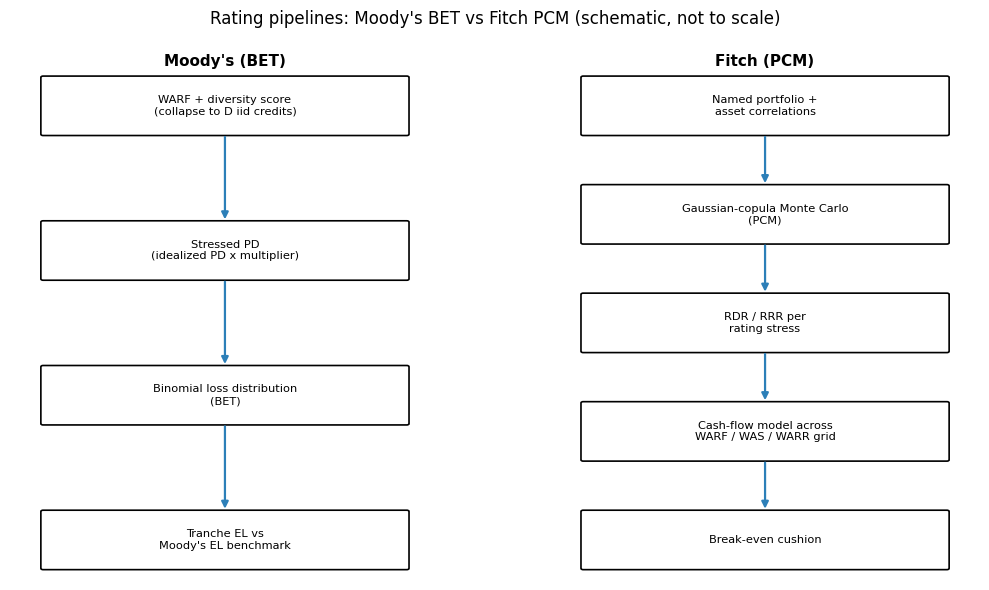

In [3]:
def draw_box(ax, x, y_center, w, h, text):
    box = FancyBboxPatch((x, y_center - h / 2), w, h, boxstyle="round,pad=0.02",
                          ec="black", fc="white", lw=1.2)
    ax.add_patch(box)
    ax.text(x + w / 2, y_center, text, ha="center", va="center", fontsize=8.2)

def draw_column(ax, x, steps, w=3.3, h=0.85, top=6.5, bottom=0.0):
    ys = np.linspace(top, bottom, len(steps))
    for y, txt in zip(ys, steps):
        draw_box(ax, x, y, w, h, txt)
    for y0, y1 in zip(ys[:-1], ys[1:]):
        ax.annotate("", xy=(x + w / 2, y1 + h / 2), xytext=(x + w / 2, y0 - h / 2),
                    arrowprops=dict(arrowstyle="-|>", color=ACCENT, lw=1.6))
    return ys

moodys_steps = ["WARF + diversity score\n(collapse to D iid credits)",
                "Stressed PD\n(idealized PD x multiplier)",
                "Binomial loss distribution\n(BET)",
                "Tranche EL vs\nMoody's EL benchmark"]
fitch_steps = ["Named portfolio +\nasset correlations",
               "Gaussian-copula Monte Carlo\n(PCM)",
               "RDR / RRR per\nrating stress",
               "Cash-flow model across\nWARF / WAS / WARR grid",
               "Break-even cushion"]

fig, ax = plt.subplots(figsize=(10, 6))
draw_column(ax, 0.3, moodys_steps)
draw_column(ax, 5.2, fitch_steps)
ax.text(0.3 + 1.65, 7.1, "Moody's (BET)", ha="center", fontsize=11, fontweight="bold")
ax.text(5.2 + 1.65, 7.1, "Fitch (PCM)", ha="center", fontsize=11, fontweight="bold")
ax.set_xlim(0, 8.8)
ax.set_ylim(-0.6, 7.6)
ax.axis("off")
ax.set_title("Rating pipelines: Moody's BET vs Fitch PCM (schematic, not to scale)")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_pipeline_schematic.png", dpi=150)
plt.show()

**Reading this figure:** both pipelines end in a pass/fail test against a
stress scenario, but Moody's collapses the portfolio to a statistic (WARF,
diversity score) before stressing it, while Fitch stresses the named
portfolio directly and folds the cash-flow waterfall into the same step.
**[VERIFIED -- mechanism only, public methodology summaries; diagram is a
schematic, not to scale]**

## 2. What changed

The table below is the notebook's parameter diff. Cells read "n/a -- pending
redline" where the public record does not yet specify a value; nothing here
is fabricated to fill a gap.

In [4]:
cols = ["Parameter", "Moody's Apr-2026", "Moody's Jun-2026 RfC", "Fitch prior",
        "Fitch Jun-2026", "S&P (current)", "Binding for", "Status"]
diff_rows_general = [
    ("Default-prob. stress multiplier -- Aaa", "1.95", "1.81", "n/a", "n/a",
     "n/a (SDR quantile calibration, not a stress multiplier)",
     "Moody's Aaa tranches", "TO-VERIFY (RfC exhibit; commentary source)"),
    ("Default-prob. stress multiplier -- Aa/A/Baa/Ba/B", "existing ladder",
     "n/a -- pending redline", "n/a", "n/a", "n/a",
     "Moody's non-Aaa tranches", "TO-VERIFY (full ladder not public)"),
    ("Collateral attribute basis", "covenanted (matrix)", "proposed: actual portfolio",
     "covenanted (matrix)", "n/a -- pending redline", "actual (stable quality + CDOM)",
     "all three, mechanics differ", "Moody's/Fitch mechanism VERIFIED; S&P VERIFIED"),
    ("Recovery rate table", "2019 vintage", "unchanged (reportedly identical)",
     "existing table", "n/a -- pending redline", "recovery ratings 1+ through 6 (2019 criteria)",
     "Moody's", "TO-VERIFY (commentary); S&P structure VERIFIED, values TO-VERIFY"),
    ("Correlation assumptions", "existing", "unchanged", "existing",
     "n/a -- pending redline", "existing (2019 criteria appendices)",
     "Moody's", "TO-VERIFY (commentary); S&P values TO-VERIFY"),
    ("Overall note-rating impact", "n/a", "~1/3 of classes, 1-3 notch upgrade (projected)",
     "n/a", "5-15% of notes, all positive", "no update identified -- stationary/control group",
     "all three", "TO-VERIFY (agency self-estimates); S&P status TO-VERIFY"),
]

In [5]:
diff_rows_sp = [
    ("S&P PD source", "n/a", "n/a", "n/a", "n/a",
     "S&P ratings / credit assessments + default tables",
     "S&P sizing basis", "structure VERIFIED; values TO-VERIFY"),
    ("S&P correlation assumptions (inter/intra-industry, regional)", "n/a", "n/a", "n/a", "n/a",
     "CDO Evaluator correlation matrix (2019 criteria appendices)",
     "S&P AAA sizing", "structure VERIFIED; values TO-VERIFY from 2019 appendices"),
    ("S&P recovery framework", "n/a", "n/a", "n/a", "n/a",
     "recovery ratings 1+, 1, 2, 3, 4, 5, 6 tiers",
     "S&P mezz/junior sizing", "structure VERIFIED; tier values TO-VERIFY"),
    ("S&P collateral basis", "n/a", "n/a", "n/a", "n/a",
     "actual portfolio, via stable quality approach + CDOM reinvestment test",
     "S&P manager trading flexibility", "VERIFIED"),
    ("S&P rating benchmark", "n/a", "n/a", "n/a", "n/a",
     "rating quantiles / target portfolio default benchmarks (e.g. 1.829% SDR quantile)",
     "S&P all tranches", "mechanism VERIFIED; specific quantile table TO-VERIFY"),
]
diff_df = pd.DataFrame(diff_rows_general + diff_rows_sp, columns=cols)
styled = (diff_df.style
          .set_properties(**{"text-align": "left", "white-space": "pre-wrap"})
          .set_table_styles([{"selector": "th", "props": [("text-align", "left")]}])
          .hide(axis="index"))
styled

Parameter,Moody's Apr-2026,Moody's Jun-2026 RfC,Fitch prior,Fitch Jun-2026,S&P (current),Binding for,Status
Default-prob. stress multiplier -- Aaa,1.95,1.81,n/a,n/a,"n/a (SDR quantile calibration, not a stress multiplier)",Moody's Aaa tranches,TO-VERIFY (RfC exhibit; commentary source)
Default-prob. stress multiplier -- Aa/A/Baa/Ba/B,existing ladder,n/a -- pending redline,n/a,n/a,n/a,Moody's non-Aaa tranches,TO-VERIFY (full ladder not public)
Collateral attribute basis,covenanted (matrix),proposed: actual portfolio,covenanted (matrix),n/a -- pending redline,actual (stable quality + CDOM),"all three, mechanics differ",Moody's/Fitch mechanism VERIFIED; S&P VERIFIED
Recovery rate table,2019 vintage,unchanged (reportedly identical),existing table,n/a -- pending redline,recovery ratings 1+ through 6 (2019 criteria),Moody's,"TO-VERIFY (commentary); S&P structure VERIFIED, values TO-VERIFY"
Correlation assumptions,existing,unchanged,existing,n/a -- pending redline,existing (2019 criteria appendices),Moody's,TO-VERIFY (commentary); S&P values TO-VERIFY
Overall note-rating impact,n/a,"~1/3 of classes, 1-3 notch upgrade (projected)",n/a,"5-15% of notes, all positive",no update identified -- stationary/control group,all three,TO-VERIFY (agency self-estimates); S&P status TO-VERIFY
S&P PD source,n/a,n/a,n/a,n/a,S&P ratings / credit assessments + default tables,S&P sizing basis,structure VERIFIED; values TO-VERIFY
"S&P correlation assumptions (inter/intra-industry, regional)",n/a,n/a,n/a,n/a,CDO Evaluator correlation matrix (2019 criteria appendices),S&P AAA sizing,structure VERIFIED; values TO-VERIFY from 2019 appendices
S&P recovery framework,n/a,n/a,n/a,n/a,"recovery ratings 1+, 1, 2, 3, 4, 5, 6 tiers",S&P mezz/junior sizing,structure VERIFIED; tier values TO-VERIFY
S&P collateral basis,n/a,n/a,n/a,n/a,"actual portfolio, via stable quality approach + CDOM reinvestment test",S&P manager trading flexibility,VERIFIED


### 2.1 The multiplier change

The headline RfC number is a reduction in the Aaa default-probability stress
multiplier from 1.95 to 1.81 **[TO-VERIFY against RfC exhibit; sourced from
third-party commentary, full ladder by rating unknown]**. Mechanically this
multiplier scales the idealized default probability up before it is fed into
the BET as the per-credit stressed PD -- a smaller multiplier means a lower
stressed PD, a thinner loss tail, and a lower attachment point clears the
same EL benchmark. Section 3 builds this out explicitly.

### 2.2 Covenanted -> actual collateral attributes

The RfC proposes moving the binding collateral input from the covenanted
matrix (the worst-case combination of WARF/diversity/spread/recovery the
manager is permitted to trade to) to the portfolio's actual measured
attributes **[VERIFIED -- mechanism is stated in the RfC]**. For a portfolio
that is running better than its covenants, which is the common mid-life
case, this is a de facto credit-positive input change independent of the
multiplier. Section 4 sizes this effect on a synthetic deal set.

### 2.3 What did not change, and why that asymmetry matters

Recovery rate assumptions and correlation assumptions are reportedly
unchanged: the recovery table is said to match the 2019 vintage table
**[TO-VERIFY -- third-party commentary]**. Holding recoveries and
correlation fixed while lowering the default-probability stress is an
asymmetric move: it directly reduces the modeled probability of loss without
touching the modeled severity-given-default or the modeled co-movement of
defaults in a downturn. If realized correlation or realized recovery in a
future stress period is worse than the frozen assumptions, the multiplier
relief does not have an offsetting conservatism elsewhere in the model to
absorb it. This is the central objection in the public commentary discussed
below, and it is a fair one to weigh independent of where the final
multiplier lands.

### 2.4 S&P: the stationary benchmark

S&P's CLO framework is **CDO Evaluator**, a simulation model producing
**scenario default rates (SDRs)** per rating level: rating quantiles are the
principal calibration device, so that, for example, a 1.829% quantile
identifies the gross default level such that modeled P(defaults exceed it)
equals 1.829%. Structural analysis runs through **Cash Flow Evaluator**,
which stresses default levels and timing, recovery levels and timing,
interest rates, and prepayments to produce **break-even default rates
(BDRs)**. **Supplemental tests** (largest obligor, largest industry) sit
alongside the main SDR/BDR analysis; any of the three may constrain the
tranche rating. **[VERIFIED -- S&P criteria documents and CDO Monitor
commentary]**

S&P's current global CLO criteria date to **June 21, 2019**; no 2026 update
was identified in public sources as of this notebook's date (Jul 8, 2026).
**[TO-VERIFY -- no update identified; confirm with desk / RatingsDirect]** If
confirmed, S&P is the control group for this notebook: the stationary
benchmark against which the Moody's and Fitch June 2026 moves are measured.

Under S&P's **stable quality approach**, adopted by post-crisis CLOs in both
the U.S. and Europe, credit and cash flow analysis focuses primarily on the
**actual portfolio**, with the manager committing in the documents to run
the **CDO Monitor (CDOM) test** when reinvesting; if the test fails, the
manager must maintain or improve results with subsequent trades.
**[VERIFIED]**

Moody's proposed covenanted-to-actual switch (Section 2.2) is partial
convergence toward the approach S&P has used since CLO 2.0 -- so S&P's CDOM
mechanics preview what Moody's surveillance dynamics look like once that
change takes effect. Section 6 returns to this point.

### 2.5 Context: sequencing and public commentary

Fitch published its final updated criteria around June 1, 2026. Moody's,
having finalized its own methodology on April 24, 2026, put out a further
RfC on June 5, 2026, one month later, proposing relief in the same
direction. **[VERIFIED -- timeline, agency public announcements]** This
sequencing has drawn public criticism characterizing it as a round of
competitive criteria relaxation between the two agencies **[commentary, not
fact about motive -- see Dubitsky, reference 5]**. The notebook treats that
characterization as commentary throughout and does not adopt it as an
analytical premise; the multiplier and collateral-basis changes are analyzed
on their own mechanical terms in Sections 3 and 4.

## 3. The multiplier change, intuitively

This section builds a minimal BET from scratch and runs it on one
illustrative portfolio, purely to show the *shape* of the multiplier effect.
None of the following numbers are Moody's actual parameters unless labeled
VERIFIED; where an exact input (the idealized Aaa PD, the Aaa EL benchmark)
is not available locally, it is set to `None` with an illustrative
order-of-magnitude stand-in, and every figure title says ILLUSTRATIVE.

In [6]:
def bet_loss_dist(D, p, recovery):
    """Binomial loss distribution over D iid credits at default prob p."""
    k = np.arange(D + 1)
    pk = st.binom.pmf(k, D, p)
    losses = k / D * (1 - recovery)
    return losses, pk

def tranche_el(losses, pk, attach, detach):
    """Expected loss of a tranche given a discrete loss distribution."""
    width = detach - attach
    sev = np.clip(losses - attach, 0, width) / width
    return float((sev * pk).sum())

def min_attach_for_el(D, p, recovery, el_target, detach=1.0, grid=2001):
    """Smallest attachment point whose tranche EL is at or below el_target."""
    losses, pk = bet_loss_dist(D, p, recovery)
    for attach in np.linspace(0, detach, grid):
        if tranche_el(losses, pk, attach, detach) <= el_target:
            return attach
    return detach

In [7]:
CONFIG = {
    "diversity_score": 60,     # ILLUSTRATIVE
    "wal_years": 6,            # ILLUSTRATIVE
    "recovery": 0.45,          # ILLUSTRATIVE -- broad senior secured leveraged loan assumption
    "multiplier_old": 1.95,    # TO-VERIFY -- third-party commentary on Moody's Apr-2026 methodology
    "multiplier_new": 1.81,    # TO-VERIFY -- third-party commentary on Moody's Jun-2026 RfC
}

# The WARF-implied portfolio-average 6-year cumulative default probability
# (what the multiplier actually stresses -- not an idealized Aaa PD in its
# own right) and the Aaa EL benchmark at that WAL are not in docs/criteria/
# locally. Both are left as None with an illustrative stand-in so the
# figures below can show the multiplier's effect on shape without claiming
# Moody's real numbers.
IDEALIZED_PORTFOLIO_PD_6Y = None
EL_BENCHMARK_AAA_6Y = None

illustrative_base_pd = IDEALIZED_PORTFOLIO_PD_6Y or 0.20        # ILLUSTRATIVE placeholder
illustrative_el_target = EL_BENCHMARK_AAA_6Y or 0.000001        # ILLUSTRATIVE placeholder

D = CONFIG["diversity_score"]
recovery = CONFIG["recovery"]
stressed_pd_old = illustrative_base_pd * CONFIG["multiplier_old"]
stressed_pd_new = illustrative_base_pd * CONFIG["multiplier_new"]
mult_old, mult_new = CONFIG["multiplier_old"], CONFIG["multiplier_new"]
print(f"Stressed PD, old multiplier ({mult_old}): {stressed_pd_old:.4%}")
print(f"Stressed PD, new multiplier ({mult_new}): {stressed_pd_new:.4%}")

Stressed PD, old multiplier (1.95): 39.0000%
Stressed PD, new multiplier (1.81): 36.2000%


### Figure 1 -- loss distribution shift

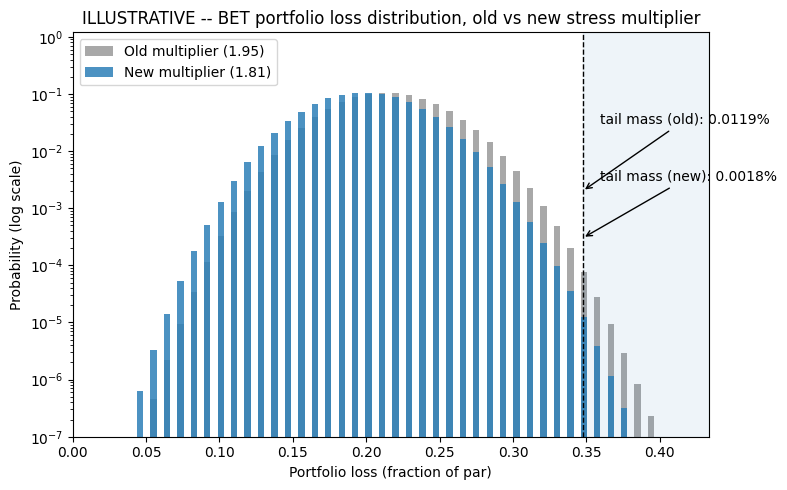

In [8]:
losses_old, pk_old = bet_loss_dist(D, stressed_pd_old, recovery)
losses_new, pk_new = bet_loss_dist(D, stressed_pd_new, recovery)
candidate_attach = min_attach_for_el(D, stressed_pd_old, recovery, illustrative_el_target)
tail_old = pk_old[losses_old > candidate_attach].sum()
tail_new = pk_new[losses_new > candidate_attach].sum()

visible_support = losses_old[pk_old > 1e-7].max()
x_max = min(1.0, max(visible_support, candidate_attach) * 1.1)
fig, ax = plt.subplots(figsize=(8, 5))
width = 0.6 * x_max / D
ax.bar(losses_old, pk_old, width=width, color="0.6", alpha=0.85,
       label=f"Old multiplier ({CONFIG['multiplier_old']})")
ax.bar(losses_new, pk_new, width=width, color=ACCENT, alpha=0.85,
       label=f"New multiplier ({CONFIG['multiplier_new']})")
ax.axvline(candidate_attach, color="black", ls="--", lw=1)
ax.axvspan(candidate_attach, x_max, color=ACCENT, alpha=0.08)
ax.annotate(f"tail mass (old): {tail_old:.4%}", xy=(candidate_attach, 2e-3),
            xytext=(candidate_attach + 0.012, 3e-2), arrowprops=dict(arrowstyle="->"))
ax.annotate(f"tail mass (new): {tail_new:.4%}", xy=(candidate_attach, 3e-4),
            xytext=(candidate_attach + 0.012, 3e-3), arrowprops=dict(arrowstyle="->"))
ax.set_yscale("log")
ax.set_ylim(1e-7, 1.2)
ax.set_xlim(0, x_max)
ax.set_xlabel("Portfolio loss (fraction of par)")
ax.set_ylabel("Probability (log scale)")
ax.set_title("ILLUSTRATIVE -- BET portfolio loss distribution, old vs new stress multiplier")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "02_loss_distribution_shift.png", dpi=150)
plt.show()

**Reading this figure:** the lower multiplier scales down the stressed
default probability applied to each of the D independent credits, which
thins the probability mass in the tail beyond the candidate Aaa attachment
point. **[TO-VERIFY -- illustrative portfolio, not a real deal; multiplier
values per third-party commentary on the RfC]**

### Figure 2 -- required subordination ladder

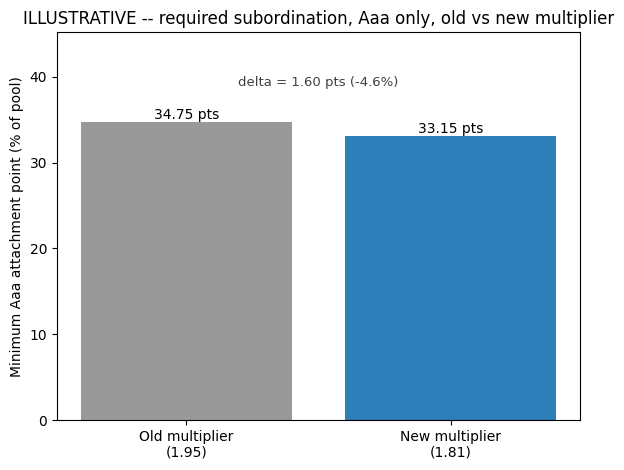

In [9]:
attach_old = min_attach_for_el(D, stressed_pd_old, recovery, illustrative_el_target)
attach_new = min_attach_for_el(D, stressed_pd_new, recovery, illustrative_el_target)
delta_pts = (attach_old - attach_new) * 100
vals = [attach_old * 100, attach_new * 100]
rel_pct = 100 * delta_pts / vals[0]

fig, ax = plt.subplots(figsize=(6, 4.8))
bars = ax.bar(["Old multiplier\n(1.95)", "New multiplier\n(1.81)"], vals, color=["0.6", ACCENT])
for b, v in zip(bars, vals):
    ax.annotate(f"{v:.2f} pts", xy=(b.get_x() + b.get_width() / 2, v), ha="center", va="bottom")
ax.text(0.5, max(vals) * 1.12, f"delta = {delta_pts:.2f} pts (-{rel_pct:.1f}%)",
        ha="center", fontsize=9.5, color="0.25")
ax.set_ylim(0, max(vals) * 1.3)
ax.set_ylabel("Minimum Aaa attachment point (% of pool)")
ax.set_title("ILLUSTRATIVE -- required subordination, Aaa only, old vs new multiplier")
fig.tight_layout()
fig.savefig(FIG_DIR / "03_subordination_ladder.png", dpi=150)
plt.show()

**Reading this figure:** on this illustrative portfolio the multiplier
change alone lowers the minimum Aaa attachment by the annotated delta, a
relative reduction in the same single-digit-percent range as an independent
BET-replication estimate of roughly a 5% reduction in required Aaa credit
support **[TO-VERIFY -- third-party replication]**. The two are not directly
comparable in a strict sense -- this notebook's number comes from an
illustrative portfolio calibrated only to produce a plausible attachment
level, not from replicating the actual BET inputs -- but the rough
agreement in order of magnitude is a reasonable sanity check on the
mechanism. The RfC ladder for Aa/A/Baa is not available locally, so this
figure shows Aaa only.

### Figure 3 -- capital-structure comparison

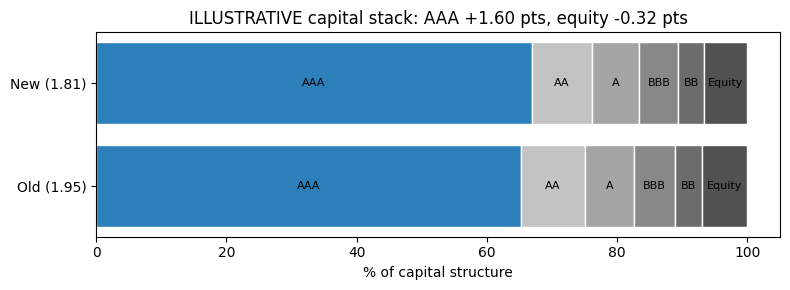

In [10]:
# ILLUSTRATIVE split of the sub-Aaa stack; not derived from a real deal.
tranche_weights = {"AA": 0.28, "A": 0.22, "BBB": 0.18, "BB": 0.12, "Equity": 0.20}

def capital_stack(attach):
    stack = {"AAA": 1 - attach}
    stack.update({k: v * attach for k, v in tranche_weights.items()})
    return stack

stack_old, stack_new = capital_stack(attach_old), capital_stack(attach_new)
labels = list(stack_old.keys())
greys = plt.cm.Greys(np.linspace(0.35, 0.75, len(labels) - 1))
colors = [ACCENT] + list(greys)

fig, ax = plt.subplots(figsize=(8, 3))
for row, stack in enumerate([stack_old, stack_new]):
    left = 0
    for lbl, c in zip(labels, colors):
        w = stack[lbl] * 100
        ax.barh(row, w, left=left, color=c, edgecolor="white")
        if w > 3:
            ax.text(left + w / 2, row, lbl, ha="center", va="center", fontsize=8)
        left += w

ax.set_yticks([0, 1])
ax.set_yticklabels(["Old (1.95)", "New (1.81)"])
ax.set_xlabel("% of capital structure")
aaa_d = (stack_new["AAA"] - stack_old["AAA"]) * 100
eq_d = (stack_new["Equity"] - stack_old["Equity"]) * 100
ax.set_title(f"ILLUSTRATIVE capital stack: AAA {aaa_d:+.2f} pts, equity {eq_d:+.2f} pts")
fig.tight_layout()
fig.savefig(FIG_DIR / "04_capital_stack.png", dpi=150)
plt.show()

**Reading this figure:** re-optimizing the same illustrative deal under the
new multiplier grows the AAA tranche and, holding the illustrative sub-Aaa
split fixed, correspondingly grows the equity slice, since less capital has
to sit between AAA and the assets. **[TO-VERIFY -- illustrative capital
structure, not a real deal]**

### Figure 4 -- arb sensitivity

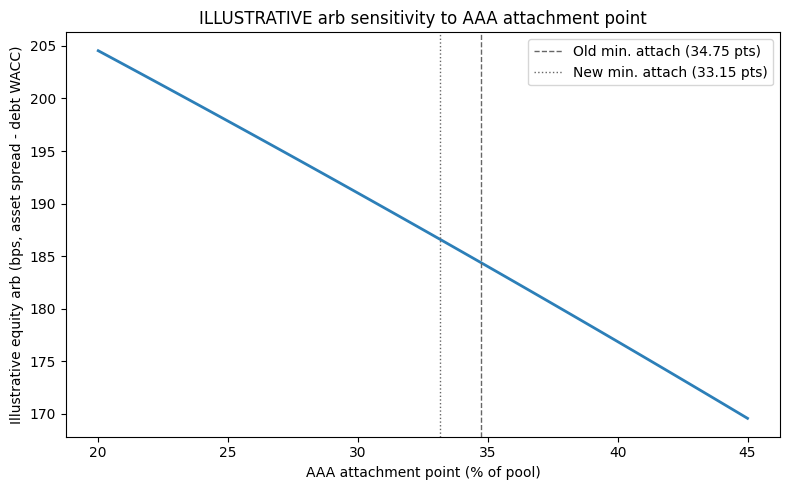

In [11]:
# TO-VERIFY -- illustrative tranche spreads and WAS, stated only to show the mechanism.
SPREADS_BPS = {"AAA": 150, "AA": 200, "A": 260, "BBB": 350, "BB": 550}
ASSET_SPREAD_BPS = 380

def wacc_bps(attach):
    stack = capital_stack(attach)
    debt = {k: v for k, v in stack.items() if k in SPREADS_BPS}
    debt_total = sum(debt.values())
    return sum(debt[k] * SPREADS_BPS[k] for k in debt) / debt_total

attach_grid = np.linspace(0.20, 0.45, 60)
arb = [ASSET_SPREAD_BPS - wacc_bps(a) for a in attach_grid]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(attach_grid * 100, arb, color=ACCENT, lw=2)
ax.axvline(attach_old * 100, color="0.4", ls="--", lw=1, label=f"Old min. attach ({attach_old * 100:.2f} pts)")
ax.axvline(attach_new * 100, color="0.4", ls=":", lw=1, label=f"New min. attach ({attach_new * 100:.2f} pts)")
ax.set_xlabel("AAA attachment point (% of pool)")
ax.set_ylabel("Illustrative equity arb (bps, asset spread - debt WACC)")
ax.set_title("ILLUSTRATIVE arb sensitivity to AAA attachment point")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "05_arb_sensitivity.png", dpi=150)
plt.show()

**Reading this figure:** as the multiplier compresses the minimum AAA
attachment point, the debt stack's blended cost of capital falls (AAA is the
cheapest tranche and now makes up a larger share of the debt stack), which
widens the illustrative equity arb -- this is the direct channel by which
criteria relaxation makes new issuance more attractive to equity investors.
**[TO-VERIFY -- illustrative spreads and asset WAS, not from a real deal]**

## 3b. A unified Gaussian copula engine

S&P's CDO Evaluator and Fitch's PCM natively run a factor-copula Monte Carlo.
Moody's BET is, mathematically, a moment-matching approximation of the same
underlying object: a portfolio of correlated obligors collapsed to a
tractable loss distribution. Building one copula engine and feeding it three
agencies' parameter sets puts all three methodologies in a common currency
-- correlation -- for comparison purposes.

**Role separation, stated explicitly:** the copula below is an *analysis
lens* for Moody's, used to translate BET's diversity-score mechanic into
correlation units so it can sit next to Fitch and S&P on the same axis. BET
remains the replication engine for anything claiming to reproduce a Moody's
number. Never quote a copula output as a Moody's replication result --
Section 3's BET figures are the replication; this section is commentary on
top of it. **[VERIFIED -- mechanism/framing; no agency parameter values are
asserted in this section beyond what Sections 2-3 already tagged]**

In [12]:
def cond_pd(pd_i, rho, m):
    """P(default | systemic factor M=m) under a one-factor Gaussian copula."""
    return st.norm.cdf((st.norm.ppf(pd_i) - np.sqrt(rho) * m) / np.sqrt(1 - rho))

def cond_loss_dist_given_m(pds, rho, m, recovery):
    """Poisson-binomial recursion for the loss distribution conditional on M=m."""
    p_cond = cond_pd(pds, rho, m)
    pmf = np.array([1.0])
    for p in p_cond:
        pmf = np.convolve(pmf, [1 - p, p])
    k = np.arange(len(pmf))
    losses = k / len(p_cond) * (1 - recovery)
    return losses, pmf

def loss_dist_quadrature(pds, rho, recovery, n_gh=64):
    """Deterministic one-factor Gaussian copula loss dist via Gauss-Hermite quadrature.
    hermegauss integrates against exp(-x^2/2); normalizing weights by their own
    sum converts them to N(0,1) probabilities without a separate sqrt(2*pi) constant.
    """
    nodes, weights = np.polynomial.hermite_e.hermegauss(n_gh)
    weights = weights / weights.sum()
    D = len(pds)
    total_pmf = np.zeros(D + 1)
    for m, w in zip(nodes, weights):
        _, pmf_m = cond_loss_dist_given_m(pds, rho, m, recovery)
        total_pmf += w * pmf_m
    losses = np.arange(D + 1) / D * (1 - recovery)
    return losses, total_pmf

**Multi-factor Monte Carlo, kept separate.** The quadrature engine above is
exact for a single systemic factor. A global-plus-industry block structure
needs Monte Carlo; it is kept as its own function, seeded, and is not used to
replace the deterministic engine above -- only to extend it when an
industry-block correlation structure is actually needed.

In [13]:
def loss_dist_mc(pds, corr_blocks, recovery, seed, n_paths=1_000_000):
    """Seeded two-factor (global + industry-block) Gaussian copula MC.
    corr_blocks = {"industry_id": int array len(pds), "rho_global": float, "rho_industry": float}.
    Convergence guideline: n_paths >= 1e6 for the tolerances used below.
    """
    rng = np.random.default_rng(seed)
    D = len(pds)
    industry_id = corr_blocks["industry_id"]
    n_ind = industry_id.max() + 1
    rho_g, rho_i = corr_blocks["rho_global"], corr_blocks["rho_industry"]
    m_global = rng.standard_normal(n_paths)
    m_industry = rng.standard_normal((n_paths, n_ind))
    z = rng.standard_normal((n_paths, D))
    industry_factor = m_industry[:, industry_id]
    latent = (np.sqrt(rho_g) * m_global[:, None]
              + np.sqrt(rho_i - rho_g) * industry_factor
              + np.sqrt(1 - rho_i) * z)
    thresh = st.norm.ppf(pds)
    defaults = (latent < thresh).sum(axis=1)
    k = np.arange(D + 1)
    pmf = np.bincount(defaults, minlength=D + 1) / n_paths
    losses = k / D * (1 - recovery)
    return losses, pmf

### Cross-validation: quadrature vs. seeded MC

Before either engine is used downstream, they must agree. The comparison is
run at a **bulk** attachment point (0.10-0.20), not at the ultra-thin Aaa
tail: at the Aaa el_target used in Section 3 the expected count of
tail-crossing paths in 1e6 draws is close to zero, so MC sampling noise would
swamp the comparison there. A well-sampled tranche is the right place to
validate engine agreement; Section 3's actual Aaa sizing is left to the exact
deterministic engines (BET and quadrature), never to MC.

In [14]:
test_pds = np.full(D, stressed_pd_new)
test_rho = 0.20
test_blocks = {"industry_id": np.zeros(D, dtype=int), "rho_global": test_rho, "rho_industry": test_rho}

losses_q, pmf_q = loss_dist_quadrature(test_pds, test_rho, recovery)
losses_mc, pmf_mc = loss_dist_mc(test_pds, test_blocks, recovery, seed=42, n_paths=1_000_000)

print("Quadrature vs MC agreement at bulk attachment points (seed=42, n_paths=1e6):")
max_rel_diff = 0.0
for a in [0.10, 0.15, 0.20]:
    el_q = tranche_el(losses_q, pmf_q, a, 1.0)
    el_mc = tranche_el(losses_mc, pmf_mc, a, 1.0)
    rel_diff = abs(el_q - el_mc) / el_q
    max_rel_diff = max(max_rel_diff, rel_diff)
    print(f"  attach={a:.2f}: EL_quadrature={el_q:.6f}  EL_mc={el_mc:.6f}  rel_diff={rel_diff:.3%}")

assert max_rel_diff < 0.01, "quadrature and MC disagree by more than the 3-sig-fig tolerance"
print(f"PASSED -- max relative difference {max_rel_diff:.3%}, within 3-significant-figure tolerance")

Quadrature vs MC agreement at bulk attachment points (seed=42, n_paths=1e6):
  attach=0.10: EL_quadrature=0.116575  EL_mc=0.116585  rel_diff=0.009%
  attach=0.15: EL_quadrature=0.079709  EL_mc=0.079725  rel_diff=0.019%
  attach=0.20: EL_quadrature=0.049821  EL_mc=0.049832  rel_diff=0.022%
PASSED -- max relative difference 0.022%, within 3-significant-figure tolerance


### Solvers

`min_attach` is the generic version of Section 3's `min_attach_for_el`: it
takes a precomputed (loss, probability) grid so it works for both BET's
binomial grid and the copula's quadrature grid. `implied_rho` and
`implied_diversity` invert the same target attachment point through two
different engines -- the copula and BET respectively -- which is what makes
the "correlation units" and "diversity-score units" comparisons in the
figures below meaningful.

In [15]:
def min_attach(loss_grid, probs, el_target, grid=1001):
    """Smallest attachment (0..1) whose tranche EL (to detach=1) is <= el_target.
    Vectorized: computes EL at every grid point at once and takes the first
    grid point where the (monotonically non-increasing) EL curve clears the target.
    """
    attach = np.linspace(0, 1, grid)
    width = np.maximum(1 - attach, 1e-9)
    sev = np.clip(loss_grid[None, :] - attach[:, None], 0, width[:, None]) / width[:, None]
    el = sev @ probs
    idx = np.argmax(el <= el_target)
    return attach[idx]

def implied_rho(attach_target, pds, recovery, el_target, bracket=(0.001, 0.75)):
    """Flat copula rho reproducing attach_target at the given pds/recovery/el_target.
    Bracket (0.001, 0.75): rho=0 is a measure-zero edge case for norm.ppf-based
    conditioning, and asset correlations beyond 0.75 are not economically meaningful.
    """
    def f(rho):
        losses, pmf = loss_dist_quadrature(pds, rho, recovery)
        return min_attach(losses, pmf, el_target) - attach_target
    return brentq(f, bracket[0], bracket[1], xtol=1e-4)

def implied_diversity(attach_target, p_stressed, recovery, el_target, bracket=(5, 500)):
    """BET diversity score D (continuous relaxation) reproducing attach_target.
    Illustrative inversion: D is really an integer; brentq treats it as continuous.
    """
    def f(D_cont):
        return min_attach_for_el(max(int(round(D_cont)), 1), p_stressed, recovery, el_target) - attach_target
    return brentq(f, bracket[0], bracket[1], xtol=0.5)

### Figure 5 -- implied-correlation smile

This figure needs a rating ladder, which BET alone (Section 3) does not give
us beyond Aaa. It also needs two obligor counts: BET's diversity score `D`
(60, already diversity-adjusted for correlation) and a larger raw obligor
count `N_RAW` representing the un-adjusted pool the copula lens works with.
Both the per-rating multiplier ladder and the per-rating EL-target ladder
below are illustrative placeholders -- the real ladders are exactly the
"full ladder by rating unknown" gaps flagged in Section 2's diff table.

In [16]:
N_RAW = 150   # ILLUSTRATIVE raw obligor count (D=60 is BET's diversity-adjusted count)
ratings_ladder = ["AAA", "AA", "A", "BBB", "BB"]
# ILLUSTRATIVE declining stress-multiplier ladder -- TO-VERIFY, full ladder not public (Sec. 2).
mult_new_ladder = {"AAA": CONFIG["multiplier_new"], "AA": 1.5, "A": 1.2, "BBB": 1.0, "BB": 0.8}
mult_scale = CONFIG["multiplier_old"] / CONFIG["multiplier_new"]
mult_old_ladder = {r: v * mult_scale for r, v in mult_new_ladder.items()}
mult_sp_ladder = {r: 1.0 for r in ratings_ladder}  # ILLUSTRATIVE flat S&P placeholder, not a real SDR
# ILLUSTRATIVE EL-target ladder, loosening down the stack (real benchmarks unknown -- Sec. 2).
el_ladder = {"AAA": illustrative_el_target, "AA": 8e-6, "A": 5e-5, "BBB": 3e-4, "BB": 1.5e-3}

def rho_smile(mult_ladder):
    out = {}
    for r in ratings_ladder:
        pd_r = illustrative_base_pd * mult_ladder[r]
        ce = min_attach_for_el(D, pd_r, recovery, el_ladder[r])
        out[r] = implied_rho(ce, np.full(N_RAW, pd_r), recovery, el_ladder[r])
    return out

smile_old = rho_smile(mult_old_ladder)
smile_new = rho_smile(mult_new_ladder)
smile_sp = rho_smile(mult_sp_ladder)

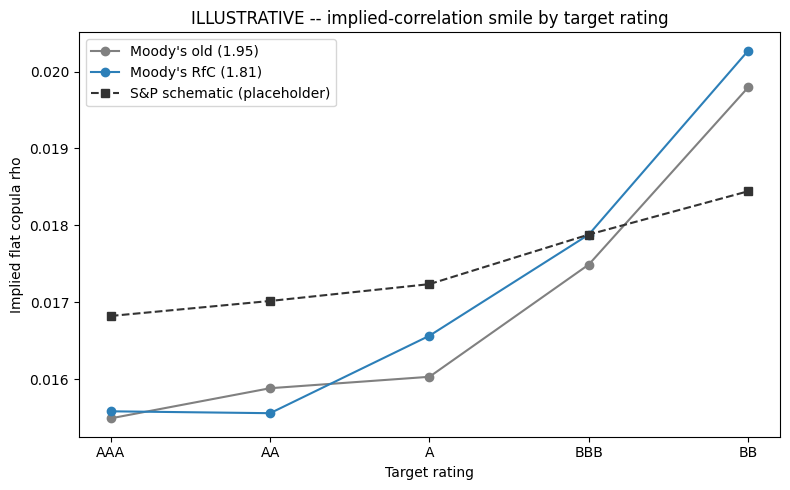

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ratings_ladder, [smile_old[r] for r in ratings_ladder], "-o", color="0.5",
        label=f"Moody's old ({CONFIG['multiplier_old']})")
ax.plot(ratings_ladder, [smile_new[r] for r in ratings_ladder], "-o", color=ACCENT,
        label=f"Moody's RfC ({CONFIG['multiplier_new']})")
ax.plot(ratings_ladder, [smile_sp[r] for r in ratings_ladder], "--s", color="0.2",
        label="S&P schematic (placeholder)")
ax.set_xlabel("Target rating")
ax.set_ylabel("Implied flat copula rho")
ax.set_title("ILLUSTRATIVE -- implied-correlation smile by target rating")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "08_implied_correlation_smile.png", dpi=150)
plt.show()

**Reading this figure:** expressed as an implied flat correlation against a
raw-obligor-count copula, the Moody's multiplier cut appears as a small
downward shift; all three curves rise gently from AAA to BB because lower
ratings tolerate looser EL targets, which a raw pool can satisfy with less
correlation only up to a point. **[TO-VERIFY -- every input (multiplier
ladder, EL-target ladder, S&P placeholder, N_RAW) is an illustrative
placeholder; only the AAA multiplier values (1.95, 1.81) carry the Section 2
TO-VERIFY tag from third-party commentary]**

### Figure 6 -- the multiplier in correlation units

Holding the illustrative PD fixed at its old-multiplier value, what flat rho
(via the N_RAW-obligor copula) or what diversity score (via BET itself)
would reproduce the same drop in the Aaa attachment point that the
multiplier cut produced? This re-expresses one number (the multiplier) in
two other units, for comparison against agencies that speak in correlation
or diversity terms rather than a PD multiplier.

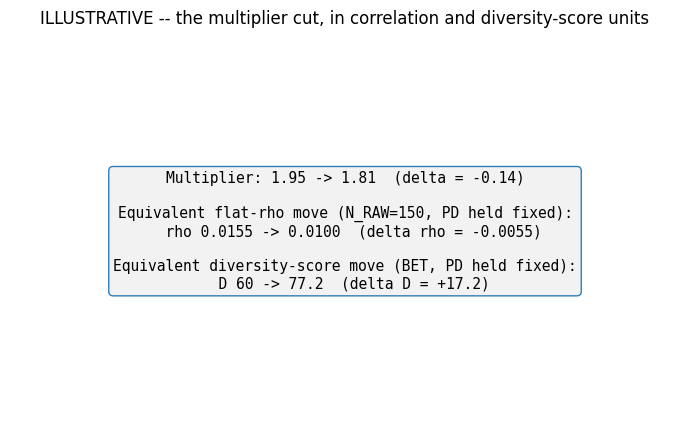

In [18]:
pds_old_flat_raw = np.full(N_RAW, stressed_pd_old)
rho_base = implied_rho(attach_old, pds_old_flat_raw, recovery, illustrative_el_target)
rho_equiv = implied_rho(attach_new, pds_old_flat_raw, recovery, illustrative_el_target)
delta_rho = rho_equiv - rho_base

D_equiv = implied_diversity(attach_new, stressed_pd_old, recovery, illustrative_el_target)
delta_D_equiv = D_equiv - D

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.axis("off")
text = (
    f"Multiplier: {CONFIG['multiplier_old']} -> {CONFIG['multiplier_new']}"
    f"  (delta = {CONFIG['multiplier_new'] - CONFIG['multiplier_old']:+.2f})\n\n"
    f"Equivalent flat-rho move (N_RAW={N_RAW}, PD held fixed):\n"
    f"  rho {rho_base:.4f} -> {rho_equiv:.4f}  (delta rho = {delta_rho:+.4f})\n\n"
    f"Equivalent diversity-score move (BET, PD held fixed):\n"
    f"  D {D} -> {D_equiv:.1f}  (delta D = {delta_D_equiv:+.1f})"
)
ax.text(0.5, 0.5, text, ha="center", va="center", fontsize=10.5, family="monospace",
        bbox=dict(boxstyle="round", fc="0.95", ec=ACCENT))
ax.set_title("ILLUSTRATIVE -- the multiplier cut, in correlation and diversity-score units")
fig.tight_layout()
fig.savefig(FIG_DIR / "09_multiplier_in_correlation_units.png", dpi=150)
plt.show()

**Reading this figure:** the same Aaa attachment-point drop can be described
as a ~0.005-0.006 flat-correlation cut in a 150-name copula, or as raising
BET's diversity score from 60 to roughly 77 -- three different-looking
levers producing the identical subordination relief. **[TO-VERIFY --
illustrative portfolio; N_RAW=150 and D=60 are placeholders, not a real
deal's obligor count or diversity score]**

### Figure 7 -- default-clustering intuition

Two seeded MC runs, same mean PD, flat rho = 0 vs 0.20 (a schematic
"agency-level" correlation, not attributed to any of the three agencies).
`loss_dist_mc` is reused here in its degenerate single-block form (one
industry, `rho_global == rho_industry`) so no separate simulation code is
needed for this illustration.

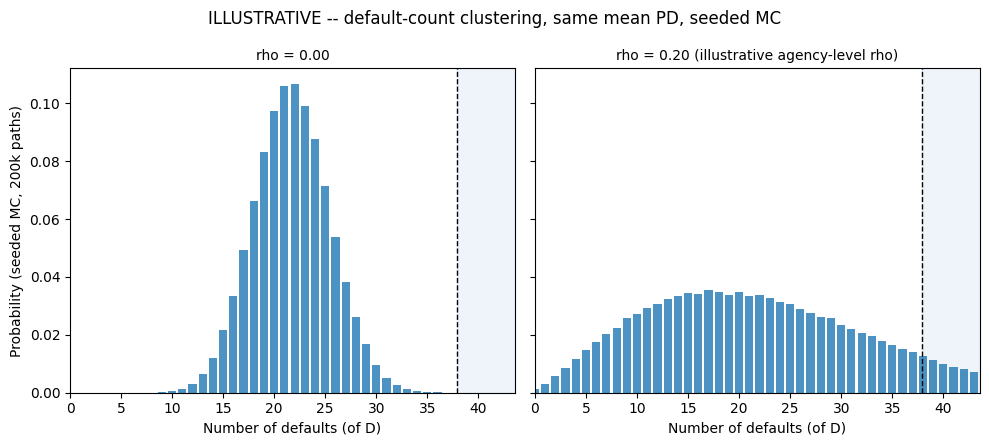

In [19]:
def flat_blocks(rho):
    return {"industry_id": np.zeros(D, dtype=int), "rho_global": rho, "rho_industry": rho}

pds_cluster = np.full(D, stressed_pd_new)
_, pmf_rho0 = loss_dist_mc(pds_cluster, flat_blocks(0.0), recovery, seed=101, n_paths=200_000)
_, pmf_rho20 = loss_dist_mc(pds_cluster, flat_blocks(0.20), recovery, seed=102, n_paths=200_000)
k = np.arange(D + 1)
k_line = candidate_attach * D / (1 - recovery)
x_max_cluster = max(k_line * 1.15, D * 0.6)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)
panels = [(pmf_rho0, "rho = 0.00"), (pmf_rho20, "rho = 0.20 (illustrative agency-level rho)")]
for ax, (pmf, lbl) in zip(axes, panels):
    ax.bar(k, pmf, color=ACCENT, alpha=0.85)
    ax.axvline(k_line, color="black", ls="--", lw=1)
    ax.axvspan(k_line, D, color=ACCENT, alpha=0.08)
    ax.set_title(lbl, fontsize=10)
    ax.set_xlabel("Number of defaults (of D)")
    ax.set_xlim(0, x_max_cluster)
axes[0].set_ylabel("Probability (seeded MC, 200k paths)")
fig.suptitle("ILLUSTRATIVE -- default-count clustering, same mean PD, seeded MC")
fig.tight_layout()
fig.savefig(FIG_DIR / "10_default_clustering.png", dpi=150)
plt.show()

**Reading this figure:** with the same average default probability, positive
correlation redistributes probability mass away from the middle and into
both tails -- more paths with very few defaults and more paths with many --
which is what makes the shaded region beyond the Aaa attachment point
visibly fatter at rho = 0.20 than at rho = 0. Correlation, not average
default probability, is what creates the tail that subordination has to
absorb. **[TO-VERIFY -- illustrative portfolio; rho = 0.20 is a schematic
value, not attributed to any agency]**

### Figure 8 -- stress-demanded curve (gated)

Needs `docs/agency_hurdles.csv` with columns `rating`, `sdr_sp`, `rdr_fitch`,
`bet_hurdle_moodys`, `vintage` -- one row per (rating, vintage) pair, each
stress-demand value expressed as a percent default rate. With the file
absent, as it is now, the cell documents the format instead of guessing
numbers.

In [20]:
AGENCY_HURDLES_PATH = Path("../docs/agency_hurdles.csv")

def plot_stress_demanded_curve(df):
    fig, ax = plt.subplots(figsize=(8, 5))
    series = [("sdr_sp", "S&P SDR", "-o"), ("rdr_fitch", "Fitch RDR", "-s"),
              ("bet_hurdle_moodys", "Moody's BET-equivalent hurdle", "-^")]
    for col, lbl, style in series:
        for vintage, sub in df.groupby("vintage"):
            ax.plot(sub["rating"], sub[col], style, label=f"{lbl} ({vintage})", alpha=0.8)
    ax.set_xlabel("Rating level")
    ax.set_ylabel("Stress-demanded default rate, %")
    ax.set_title("Stress-demanded curve: SDR vs RDR vs BET hurdle, by rating")
    ax.legend(fontsize=8)
    fig.tight_layout()
    return fig

if AGENCY_HURDLES_PATH.exists():
    hurdles_df = pd.read_csv(AGENCY_HURDLES_PATH)
    fig = plot_stress_demanded_curve(hurdles_df)
    fig.savefig(FIG_DIR / "11_stress_demanded_curve.png", dpi=150)
    plt.show()
else:
    print("No docs/agency_hurdles.csv found.")
    print("Expected columns: rating, sdr_sp, rdr_fitch, bet_hurdle_moodys, vintage")
    print("  one row per (rating, vintage) pair, values as stress-demanded default rate, percent.")
    print("plot_stress_demanded_curve(df) is ready to render it once the file exists.")

No docs/agency_hurdles.csv found.
Expected columns: rating, sdr_sp, rdr_fitch, bet_hurdle_moodys, vintage
  one row per (rating, vintage) pair, values as stress-demanded default rate, percent.
plot_stress_demanded_curve(df) is ready to render it once the file exists.


### Figure 9 -- binding-agency map (gated)

Needs the same `docs/agency_hurdles.csv`. The map is over a (WARF, obligor
count) grid: which agency's AAA constraint binds, pre- vs. post-June-2026,
with S&P held static. The structuring consequence, stated in advance of
having the data: relaxation by two agencies expands the region where the
unchanged agency (S&P, on current information) binds, which shifts agency
selection on new mandates toward whichever agency is cheapest at a given
deal's WARF/diversity combination.

In [21]:
def warf_to_pd_placeholder(warf):
    # ILLUSTRATIVE linear scaling anchored on the Section 3 portfolio -- not a real WARF-PD table.
    return illustrative_base_pd * (warf / 2800)

def binding_agency_map(hurdles_df, warf_grid, d_grid, recovery):
    """For each (WARF, D) grid point, which agency's AAA/Aaa hurdle binds (needs the most CE)."""
    aaa_row = hurdles_df.loc[hurdles_df["rating"] == "AAA"].iloc[0]
    binding = np.empty((len(warf_grid), len(d_grid)), dtype=object)
    for i, warf in enumerate(warf_grid):
        base_pd_i = warf_to_pd_placeholder(warf)
        for j, d in enumerate(d_grid):
            ce_moodys = min_attach_for_el(int(d), base_pd_i * CONFIG["multiplier_new"], recovery, illustrative_el_target)
            ce_fitch = aaa_row["rdr_fitch"] / 100
            ce_sp = aaa_row["sdr_sp"] / 100
            binding[i, j] = max([("Moody's", ce_moodys), ("Fitch", ce_fitch), ("S&P", ce_sp)], key=lambda t: t[1])[0]
    return binding

def plot_binding_map(binding, warf_grid, d_grid):
    agencies = sorted(set(binding.flatten()))
    code_map = {a: i for i, a in enumerate(agencies)}
    grid_codes = np.vectorize(code_map.get)(binding)
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.pcolormesh(d_grid, warf_grid, grid_codes, cmap="Greys", shading="auto")
    ax.set_xlabel("Diversity score (D)")
    ax.set_ylabel("WARF")
    ax.set_title("Binding-agency map: which agency's AAA constraint binds")
    handles = [plt.Rectangle((0, 0), 1, 1, color=plt.cm.Greys(code_map[a] / max(len(agencies) - 1, 1))) for a in agencies]
    ax.legend(handles, agencies, loc="upper right", fontsize=8)
    fig.tight_layout()
    return fig

In [22]:
if AGENCY_HURDLES_PATH.exists():
    hurdles_df = pd.read_csv(AGENCY_HURDLES_PATH)
    warf_grid_map = np.linspace(2000, 3500, 20)
    d_grid_map = np.arange(40, 90, 5)
    binding = binding_agency_map(hurdles_df, warf_grid_map, d_grid_map, recovery)
    fig = plot_binding_map(binding, warf_grid_map, d_grid_map)
    fig.savefig(FIG_DIR / "12_binding_agency_map.png", dpi=150)
    plt.show()
else:
    print("No docs/agency_hurdles.csv found -- same file needed as the stress-demanded curve above.")
    print("binding_agency_map(...) and plot_binding_map(...) are ready to render once it exists.")
    print("Grid needed: a WARF range and diversity-score range representative of the desk's book.")

No docs/agency_hurdles.csv found -- same file needed as the stress-demanded curve above.
binding_agency_map(...) and plot_binding_map(...) are ready to render once it exists.
Grid needed: a WARF range and diversity-score range representative of the desk's book.


### Figure 10 -- margin-of-safety surface

This one runs now, illustratively, and gets re-verified once real parameters
are in hand -- it does not depend on `docs/agency_hurdles.csv`. Required Aaa
CE is gridded over recovery (30%-45%) and a correlation offset (+0 to +10
points above an illustrative baseline rho), for the old and new Moody's
configs, using the quadrature engine so correlation is an explicit axis.

In [23]:
recovery_grid = np.linspace(0.30, 0.45, 14)
rho_offsets = np.linspace(0, 0.10, 14)
rho_base_surface = 0.015   # ILLUSTRATIVE baseline flat correlation, not an agency parameter

def ce_surface(pd_stressed, recovery_grid, rho_offsets, rho_base, el_target):
    surf = np.empty((len(rho_offsets), len(recovery_grid)))
    pds = np.full(D, pd_stressed)
    for i, dr in enumerate(rho_offsets):
        for j, rec in enumerate(recovery_grid):
            losses, pmf = loss_dist_quadrature(pds, rho_base + dr, rec, n_gh=32)
            surf[i, j] = min_attach(losses, pmf, el_target)
    return surf

surf_old = ce_surface(stressed_pd_old, recovery_grid, rho_offsets, rho_base_surface, illustrative_el_target)
surf_new = ce_surface(stressed_pd_new, recovery_grid, rho_offsets, rho_base_surface, illustrative_el_target)
vmin, vmax = min(surf_old.min(), surf_new.min()), max(surf_old.max(), surf_new.max())

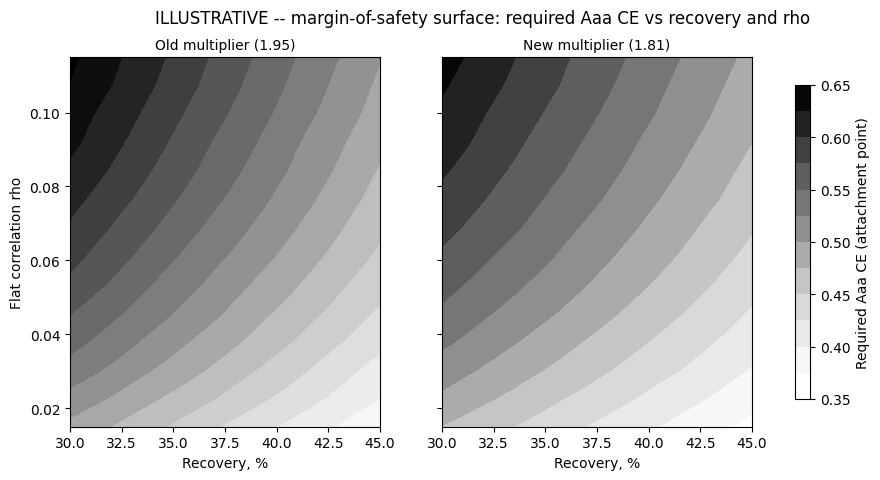

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharey=True)
for ax, surf, lbl in zip(axes, [surf_old, surf_new], ["Old multiplier (1.95)", "New multiplier (1.81)"]):
    cs = ax.contourf(recovery_grid * 100, rho_base_surface + rho_offsets, surf, levels=12,
                      cmap="Greys", vmin=vmin, vmax=vmax)
    ax.set_xlabel("Recovery, %")
    ax.set_title(lbl, fontsize=10)
axes[0].set_ylabel("Flat correlation rho")
fig.colorbar(cs, ax=axes, label="Required Aaa CE (attachment point)", shrink=0.85)
fig.suptitle("ILLUSTRATIVE -- margin-of-safety surface: required Aaa CE vs recovery and rho")
fig.savefig(FIG_DIR / "13_margin_of_safety_surface.png", dpi=150)
plt.show()

**Reading this figure:** the gap between the two panels at any fixed
(recovery, rho) point is the subordination buffer the multiplier cut
surrenders precisely where public criticism says the underlying assumptions
are stale -- recoveries reportedly at multi-year lows **[TO-VERIFY -- Fitch
research headline, Apr 2026]** and correlation assumptions unchanged
(Section 2.3). This is a way of stressing the agencies' own assumptions, not
a proposal to replace them with different ones. **[TO-VERIFY -- illustrative
grid and baseline rho, not agency parameters]**

## 4. Covenanted vs. actual collateral

The RfC's proposed switch from covenanted (matrix) attributes to actual
portfolio attributes is a second, independent lever from the multiplier
**[VERIFIED -- mechanism stated in the RfC]**. The synthetic deals below
illustrate the mechanism only; the WARF values and the notch-per-WARF-step
conversion are not from real deals or from the actual Moody's factor table.

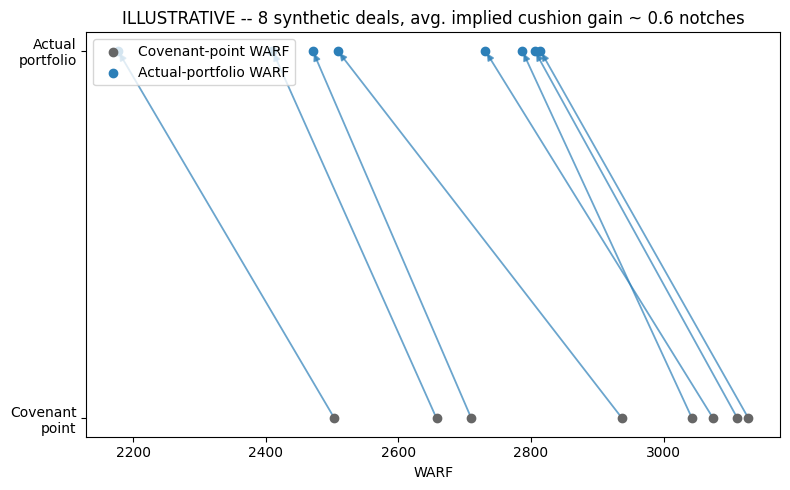

In [25]:
rng = np.random.default_rng(7)
n_deals = 8
covenant_warf = rng.uniform(2500, 3200, n_deals)
# ILLUSTRATIVE: actual portfolios trend better than the covenant ceiling mid-life.
actual_warf = covenant_warf - rng.uniform(150, 500, n_deals)

# ILLUSTRATIVE, order-of-magnitude only -- TO-VERIFY against Moody's actual rating factor table.
warf_breakpoints = {"Baa3": 610, "Ba1": 940, "Ba2": 1350, "Ba3": 1766, "B1": 2220, "B2": 2720, "B3": 3490}
avg_notch_step = np.mean(np.diff(sorted(warf_breakpoints.values())))

def implied_notches(warf_delta):
    return warf_delta / avg_notch_step

fig, ax = plt.subplots(figsize=(8, 5))
for cov, act in zip(covenant_warf, actual_warf):
    ax.annotate("", xy=(act, 1), xytext=(cov, 0),
                arrowprops=dict(arrowstyle="-|>", color=ACCENT, lw=1.3, alpha=0.7))
ax.scatter(covenant_warf, np.zeros(n_deals), color="0.4", zorder=3, label="Covenant-point WARF")
ax.scatter(actual_warf, np.ones(n_deals), color=ACCENT, zorder=3, label="Actual-portfolio WARF")
ax.set_yticks([0, 1])
ax.set_yticklabels(["Covenant\npoint", "Actual\nportfolio"])
ax.set_xlabel("WARF")
avg_gain = implied_notches((covenant_warf - actual_warf).mean())
ax.set_title(f"ILLUSTRATIVE -- 8 synthetic deals, avg. implied cushion gain ~ {avg_gain:.1f} notches")
ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig(FIG_DIR / "06_covenant_vs_actual.png", dpi=150)
plt.show()

**Reading this figure:** every synthetic deal's actual portfolio credit
quality is better than its covenant ceiling, which is typical mid-life; if
Moody's actual-portfolio proposal is finalized, that gap becomes a live
rating input rather than dead slack, worth a fraction of a rating notch of
Aaa cushion on this illustrative set, and more on individual deals with
wider covenant-to-actual gaps. **[mechanism VERIFIED -- RfC proposes actual
attributes; deal data and notch-per-WARF-step conversion ILLUSTRATIVE /
TO-VERIFY]**

This has three second-order effects worth flagging for matrix design and
surveillance. First, matrix design changes: if actual attributes bind, the
covenant matrix stops being the primary sizing constraint and becomes more
of a trading-flexibility boundary, which shifts negotiation with managers
toward how much actual-vs-covenant slack a deal is underwritten to hold.
Second, manager trading flexibility changes: a manager who has been trading
tight to covenants for structuring reasons no longer gets full credit for
that discipline unless it also improves actual portfolio stats, which could
push managers toward running measurably better books rather than merely
covenant-compliant ones. Third, and most consequential for ongoing
monitoring, surveillance dynamics change: ratings begin to drift with the
realized portfolio rather than being anchored to the covenant matrix at
close, so a deal that deteriorates within its covenants can still see rating
pressure earlier than under the current regime, and conversely a
strongly-performing deal could see upgrades sooner. This raises the value of
active portfolio monitoring on both the buy side and the structuring desk.

## 5. Fitch: what is known now, what needs the redline

Known: Fitch's updated *CLOs and Corporate CDOs Rating Criteria* is final and
effective as of roughly June 1, 2026 **[VERIFIED -- agency public
announcement]**, and Fitch estimates 5-15% of its outstanding CLO note
ratings may change as a result, with all changes in the positive direction
**[TO-VERIFY -- agency self-estimate]**. Unknown: the parameter-level
changes driving that estimate -- which RDR/RRR stress levels moved, by how
much, at which rating levels -- are not itemized in public commentary as of
this notebook's date. Anything more specific than the impact range above is
inference, not criteria text, until the redline is available.

The harness below is the comparison this section is structured around: once
two PCM output files (prior criteria and Jun-2026 criteria) are in hand, drop
them in `docs/pcm_outputs/` as CSVs with columns `rating`, `rdr_old`,
`rdr_new` (percent RDR, one row per rating level Aaa..B, indexed by
`rating`), and the cell below will render the comparison. With the directory
empty, as it is now, it prints the expected format instead of fabricating
numbers.

In [26]:
def compare_rdr_curves(rdr_old: pd.Series, rdr_new: pd.Series):
    """Plot RDR-by-rating-level, prior criteria vs Jun-2026 criteria."""
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(rdr_old.index, rdr_old.values, marker="o", color="0.5", label="Prior criteria")
    ax.plot(rdr_new.index, rdr_new.values, marker="o", color=ACCENT, label="Jun-2026 criteria")
    ax.set_xlabel("Rating level")
    ax.set_ylabel("Rating Default Rate (RDR), %")
    ax.set_title("Fitch RDR by rating level: prior vs Jun-2026 criteria")
    ax.legend()
    fig.tight_layout()
    return fig

pcm_files = sorted(PCM_DIR.glob("*.csv")) if PCM_DIR.exists() else []
if pcm_files:
    pcm_df = pd.read_csv(pcm_files[0], index_col="rating")
    fig = compare_rdr_curves(pcm_df["rdr_old"], pcm_df["rdr_new"])
    fig.savefig(FIG_DIR / "07_fitch_rdr_comparison.png", dpi=150)
    plt.show()
else:
    print("No PCM output files found in ../docs/pcm_outputs/.")
    print("Expected format once the redline is available: CSV with columns")
    print("  ['rating', 'rdr_old', 'rdr_new'], one row per rating level Aaa..B,")
    print("  RDR expressed in percent, indexed by 'rating'.")
    print("compare_rdr_curves(rdr_old, rdr_new) is ready to render it.")

No PCM output files found in ../docs/pcm_outputs/.
Expected format once the redline is available: CSV with columns
  ['rating', 'rdr_old', 'rdr_new'], one row per rating level Aaa..B,
  RDR expressed in percent, indexed by 'rating'.
compare_rdr_curves(rdr_old, rdr_new) is ready to render it.


## 6. Impact summary for the structuring desk

Pulling Sections 3 through 5 together, without any new computation.

**New-issue attachment, WACC, and arb.** On the illustrative BET in Section
3, a lower Aaa stress multiplier lowers the minimum Aaa attachment point,
which lets the AAA tranche take a larger share of the capital structure at
its low spread, which lowers the blended debt WACC, which widens the equity
arb. Every one of those steps is illustrative in magnitude here, but the
direction is not in question: this is the standard mechanical channel by
which a criteria loosening shows up as better new-issue economics, and it is
the channel a desk should expect to see first once Moody's finalizes.

**Binding-agency considerations for dual-rated deals.** For a deal rated by
both agencies, the binding constraint on any given tranche is whichever
agency's criteria requires more subordination at that rating level. If
Moody's relief moves faster or further than Fitch's already-final change,
Fitch could become the binding agency on tranches where Moody's used to
bind, and the desk's sizing exercise needs to check both engines rather than
assuming the historically-binding agency stays binding.

**Covenanted -> actual implications.** Independent of the multiplier, if the
actual-portfolio proposal is finalized as proposed, deals running better than
covenants pick up rating cushion that used to be invisible to the rating
process. This argues for tracking actual-vs-covenant gaps on the existing
book now, both to anticipate upgrade candidates and because the same
mechanism means ratings will be more sensitive to actual portfolio drift
going forward, in both directions.

**Outstanding-book upgrade screen as next step.** Moody's own estimate of
roughly one-third of outstanding classes seeing a 1-3 notch upgrade, and
Fitch's 5-15% estimate, are both agency self-estimates and both
TO-VERIFY, but they are specific enough to be actionable: the natural next
step is to screen the outstanding book against whichever of the two
mechanisms (multiplier, actual-attribute gap) plausibly applies to each deal,
rather than waiting for agency-by-agency rating actions to arrive
individually.

**S&P as the binding constraint.** If S&P's criteria are genuinely stationary
(Section 2.4 -- unconfirmed as of this notebook's date) while Moody's and
Fitch both move in the same direction, S&P becomes progressively more likely
to be the binding agency on dual- or triple-rated new issues, purely because
it stood still. A desk pricing a new deal against all three agencies should
expect S&P's relative bindingness to rise over 2026 even though nothing in
S&P's own criteria changed -- the binding-agency map in Section 3b is built
to be re-run once real hurdle data is available.

**Covenanted-to-actual imports S&P-style surveillance.** Moody's proposed
switch to actual portfolio attributes (Section 2.2, Section 4) is partial
convergence toward the surveillance dynamic S&P has run under its stable
quality approach and CDO Monitor test since CLO 2.0 (Section 2.4): ratings
that drift with the realized portfolio rather than sitting fixed to a
covenant matrix. CDOM is the closest working precedent for what Moody's
post-change surveillance is likely to look like in practice, and is worth
studying on that basis independent of whether it is ever formally
referenced by Moody's.

**Limitations, stated plainly.** Moody's numbers throughout this notebook are
RfC-provisional, not final methodology; the RfC could be finalized as
proposed, watered down, or expanded before it takes effect. The BET built in
Section 3 is a sizing engine, not the full cash-flow rating either agency
actually runs, so it will not reproduce either agency's tranche sizes
precisely even with correct inputs. Recovery and correlation assumptions are
held at the agencies' existing values throughout despite the public
criticism, noted in Section 2.3, that both are stale; this notebook does not
substitute its own alternative recovery or correlation assumptions, and that
choice is itself a source of model risk worth flagging rather than silently
resolving. The implied-correlation comparisons in Section 3b add a further
limitation of their own: they assume a flat single-factor copula, which none
of the three agencies literally uses (Moody's uses a diversity score, Fitch
and S&P use richer multi-factor / industry-block structures), so the
"smile" is a summary statistic for comparing agencies on one axis, not a
recovered model parameter for any of them.

Where this leaves the desk is an open question rather than a conclusion:
where Moody's finalizes relative to the RfC, and what the Fitch redline
shows once it is available, will determine whether the mechanical
directions traced here are a modest recalibration or something larger.

## 7. References

1. Moody's, *Global Approach to Rating Collateralized Loan Obligations*,
   Apr 24, 2026. **Primary -- obtain via registered Moody's portal; do not
   scrape.**
2. Moody's, *Proposed Methodology Update -- Request for Comment*, Jun 5,
   2026. **Primary -- obtain via registered Moody's portal; do not scrape.**
3. Fitch, *CLOs and Corporate CDOs Rating Criteria*, Jun 2026. **Primary --
   obtain via registered Fitch Ratings portal; do not scrape.**
4. Fitch, prior version of *CLOs and Corporate CDOs Rating Criteria* (via
   fitchratings.com or the NRSRO certification exhibit on SEC EDGAR).
   **Primary -- obtain via registered portal or EDGAR; do not scrape.**
5. Dubitsky, R., "Moody's and Fitch Engage in Dangerous Competitive CLO
   Relaxation Pas de Deux," Rod's Substack, Jul 2026. Source of the
   1.95 -> 1.81 multiplier figure, the recovery-table comparison, and the
   timeline critique used in Sections 2 and 3 -- cited as commentary, not as
   agency-confirmed fact.
6. Fitch, *Portfolio Credit Model User Guide* (PCM mechanics referenced in
   Section 1).
7. Cordell, L., Roberts, G., and Schwert, M., *CLO Performance*, for
   background on realized tranche and equity performance referenced in
   Section 6.
8. S&P, *Global Methodology and Assumptions for CLOs and Corporate CDOs*,
   Jun 21, 2019. **Primary -- obtain via registered S&P RatingsDirect
   portal; do not scrape.**
9. S&P, *CLO Spotlight: All You Need to Know About CDO Monitor*, Mar 2020.
10. S&P, CDO Suite of Models product documentation (CDO Evaluator, Cash
    Flow Evaluator, CDO Monitor), referenced throughout Section 2.4 and
    Section 3b.
11. S&P, earlier Request for Comment describing rating-quantile calibration
    for CDO Evaluator, referenced in Section 2.4.